# ARIMAX - ARIMA with Exogenous Regressors

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

df = pd.read_csv("../Data/arimax2.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
df.head()

,sales,price_index,ad_spend,competitor_price
date,,,,
2018-01-01,0.000000,100.596057,41.915064,100.124125
2018-02-01,209.055572,101.034083,44.982430,102.382841
2018-03-01,340.310518,102.909277,59.154021,103.233365
2018-04-01,397.500802,104.427636,53.287511,103.349891
2018-05-01,508.866417,102.251067,95.725004,101.275955


In [18]:
y = df["sales"].astype(float)
X = df[["price_index", "ad_spend", "competitor_price"]].astype(float)


test_horizon = 12
y_train, y_test = y.iloc[:-test_horizon], y.iloc[-test_horizon:]
X_train, X_test = X.iloc[:-test_horizon], X.iloc[-test_horizon:]

In [20]:
#Auto-ARIMA to select orders (with exogenous)
#Tune bounds if needed, m=12 assumes monthly data with yearly seasonality.
auto = pm.auto_arima(
    y_train,
    X=X_train,
    seasonal=True,
    m=12,
    stepwise=True,
    information_criterion="aic",
    max_p=5, max_q=5, max_order=None,
    max_P=2, max_Q=2,
    d=None, D=None,           #let it infer differencing?
    start_p=0, start_q=0, start_P=0, start_Q=0,
    trace=False,
    error_action="ignore",
    suppress_warnings=True
)

print("Selected nonseasonal order (p,d,q):", auto.order)
print("Selected seasonal order (P,D,Q,m):", auto.seasonal_order)

(p, d, q) = auto.order
(P, D, Q, m) = auto.seasonal_order

Selected nonseasonal order (p,d,q): (2, 0, 1)
Selected seasonal order (P,D,Q,m): (0, 0, 0, 12)


In [22]:
#Refit in statsmodels SARIMAX with chosen orders
mod = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res = mod.fit(disp=False)
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   72
Model:               SARIMAX(2, 0, 1)   Log Likelihood                -295.549
Date:                Wed, 15 Oct 2025   AIC                            607.098
Time:                        14:49:51   BIC                            625.086
Sample:                    01-01-2018   HQIC                           614.243
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            4.6448     12.795      0.363      0.717     -20.433      29.723
price_index         -2.8158      4.645     -0.606      0.544     -11.921       6.289
ad_spend             1.5879 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


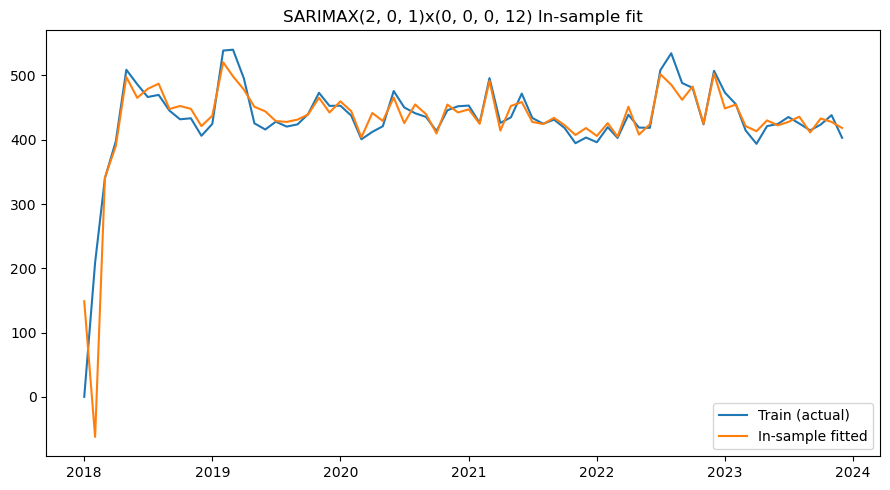

In [24]:
#In-sample fit
fitted = res.get_prediction().predicted_mean
plt.figure(figsize=(9,5))
plt.plot(y_train.index, y_train, label="Train (actual)")
plt.plot(y_train.index, fitted, label="In-sample fitted")
plt.title(f"SARIMAX{(p,d,q)}x{(P,D,Q,m)} In-sample fit")
plt.legend()
plt.tight_layout()
plt.show()

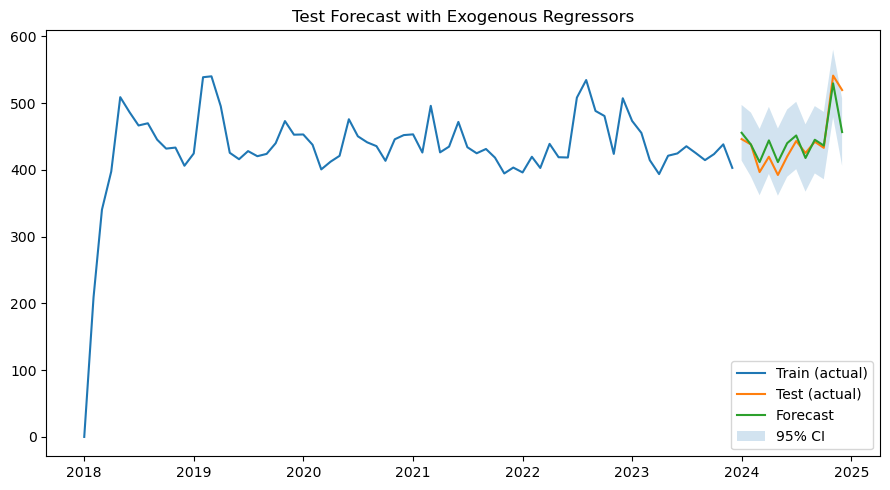

In [26]:
#Out-of-sample forecast
fcst_res = res.get_forecast(steps=len(y_test), exog=X_test)
y_hat = fcst_res.predicted_mean
ci = fcst_res.conf_int()

plt.figure(figsize=(9,5))
plt.plot(y_train.index, y_train, label="Train (actual)")
plt.plot(y_test.index, y_test, label="Test (actual)")
plt.plot(y_test.index, y_hat, label="Forecast")
plt.fill_between(y_test.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.2, label="95% CI")
plt.title("Test Forecast with Exogenous Regressors")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
mae  = float(np.mean(np.abs(y_test - y_hat)))
mape = float(np.mean(np.abs((y_test - y_hat) / y_test)) * 100)
print(f"Test MAE:  {mae:,.3f}")
print(f"Test MAPE: {mape:,.2f}%")

Test MAE:  15.415
Test MAPE: 3.40%


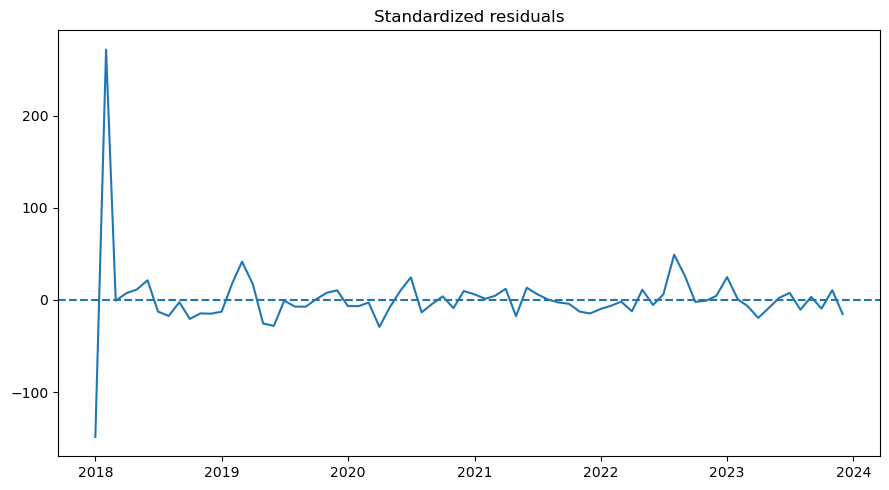

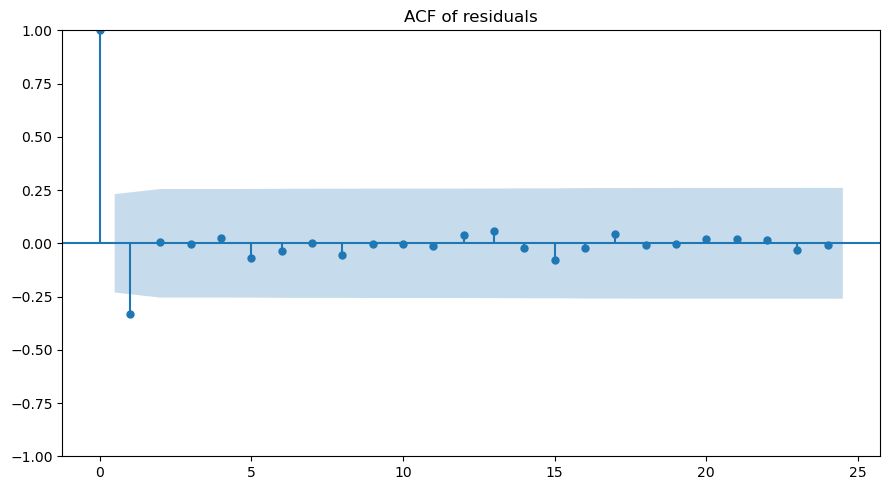

In [30]:
#Residual diagnostics
resid = pd.Series(res.resid, index=y_train.index).astype(float)

plt.figure(figsize=(9,5))
plt.plot(resid.index, resid)
plt.axhline(0, linestyle="--")
plt.title("Standardized residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sm.graphics.tsa.plot_acf(resid.dropna(), lags=24, ax=plt.gca())
plt.title("ACF of residuals")
plt.tight_layout()
plt.show()

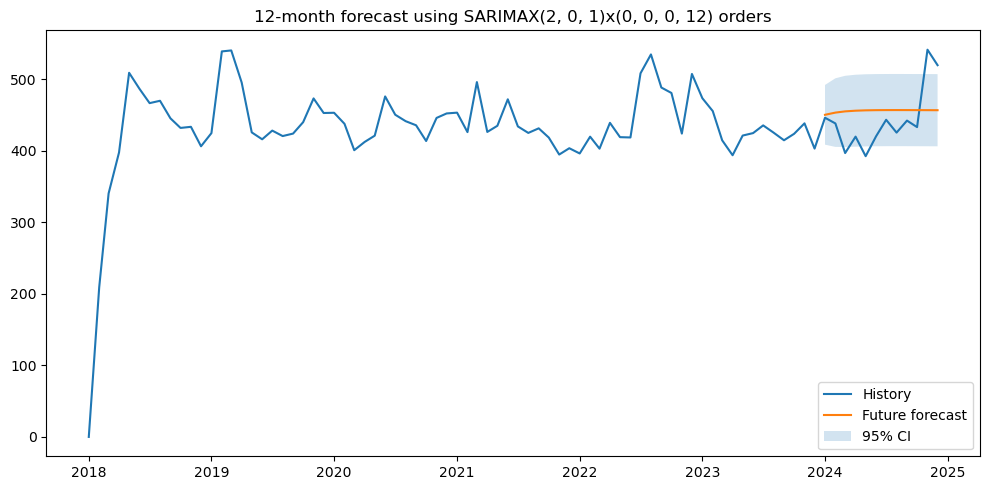

In [32]:
#Future forecast (needs exogenous path) 
future_steps = 12
future_index = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq="MS")
X_future = pd.DataFrame({
    "price_index": np.full(future_steps, X.iloc[-1, 0]),
    "ad_spend": np.full(future_steps, X.iloc[-1, 1]),
    "competitor_price": np.full(future_steps, X.iloc[-1, 2]),
}, index=future_index)

future_fcst = res.get_forecast(steps=future_steps, exog=X_future)
future_mean = future_fcst.predicted_mean
future_ci = future_fcst.conf_int()

plt.figure(figsize=(10,5))
plt.plot(y.index, y, label="History")
plt.plot(future_mean.index, future_mean, label="Future forecast")
plt.fill_between(future_mean.index, future_ci.iloc[:,0], future_ci.iloc[:,1], alpha=0.2, label="95% CI")
plt.title(f"12-month forecast using SARIMAX{(p,d,q)}x{(P,D,Q,m)} orders")
plt.legend()
plt.tight_layout()
plt.show()